# further classifications

In [3]:
import os
from pathlib import Path
import pandas as pd
import duckdb as ddb
from connection_helper import sql
from pandas_plots import tbl, pls, hlp
from pandas_plots.hlp import add_bitmask_label
import duckdb as ddb

hlp.show_package_version(["pygwalker"])
os.environ['THEME']='light'
os.environ['DEBUG']='1'

dir_db=Path("C://temp") if hlp.get_os(hlp.OperatingSystem.WINDOWS) else Path(os.path.expanduser("~/tmp"))

file_db_clin = dir_db/'2026-02-26_data_clin.duckdb'
# file_db_clin = dir_db/'2025-11-11_data_clin.duckdb'
if not file_db_clin.exists():
    exit()

if not os.path.exists(".local"):
    os.makedirs(".local")

🐍 3.12.8 | 📦 pygwalker: 0.5.0.0 | 📦 pandas: 2.3.3 | 📦 numpy: 1.26.4 | 📦 duckdb: 1.4.4 | 📦 pandas-plots: 1.2.6 | 📦 connection-helper: 0.13.3


In [4]:
con = ddb.connect(":memory:")
# con = ddb.connect(file_db_clin, read_only=True)
_=con.execute("PRAGMA disable_progress_bar;")
_=con.execute(f"ATTACH DATABASE '{file_db_clin}' AS clin (READ_ONLY); SET SCHEMA 'clin';")
_=con.execute("ATTACH DATABASE ':memory:' AS mem;")


## <a id='toc1_1_'></a>[📆 data as of](#toc0_)

In [5]:
sql.print_meta(file_db_clin)

database file:           2026-02-26_data_clin.duckdb
data tag:                v2.4
last kkr data import:    2026-02-24
sql table created:       2026-02-26 16:43:32
doi:                     -
document created:        2026-03-02 19:03:21


In [6]:
# # * list all
print()
con.sql("""select distinct(Name) from Diagnose_WeitereKlassifikation order by Name""").to_df().Name.tolist()

['13q14',
 '19q',
 '1p',
 'AAIPI',
 'ABSTANDPT_MM',
 'ADOREG',
 'AEG',
 'AEG (Ösophagus)',
 'AEG n Siewert',
 'AEG nach Siewert',
 'AEG-Typ (Siewert)',
 'AEG/Siewert (Ösophagus/Kardia)',
 'AEG/Siewert-Klassifikation',
 'AFIP',
 'AFP ( Alpha-1-Fetoprotein)',
 'AJC - Osteosarkome',
 'AJC - Weichteile',
 'AJC/UICC',
 'AJCC',
 'AJCC (Haut)',
 'AJCC (Magen)',
 'AJCC (nicht Haut)',
 'AJCC 2016',
 'AJCC Klassifikation MM 2016',
 'AJCC Stadieneinteilung MM 2017',
 'AJCC+TNM (Malignes Melanom)',
 'AJCC-STADIUM',
 'AJCC-Stadieneinteilung',
 'AJCC-malignes Melanom',
 'ALK',
 'AML ELN - C92.0',
 'AML ELN-Klassifikation (2010)',
 'AML EuropLeukNet 2017',
 'AML EuropLeukNet 2017 (ELN)',
 'AML EuropLeukNet 2022',
 'AML European Leukemia Net',
 'AML European LeukemiaNet',
 'ANN-ARBOR',
 'ANN_ARBOR',
 'ANN_ARBOR_ALLGEMEIN',
 'ANN_ARBOR_BULKY',
 'ANN_ARBOR_EXTRA',
 'ANN_ARBOR_MILZ',
 'ANN_ARBOR_STADIUM',
 'ANN_ARBOR_ZUSATZ',
 'AP (alkalische Phosphatase)',
 'ASA Risikoklassifikation',
 'Adenokarzinome d

In [7]:
with open("../../sql/check_if_class.sql") as f:
    _macro_check_if_class = f.read()
_=con.execute(_macro_check_if_class)

In [8]:
db_class = (con.sql("""--sql
        with dia_fol as (
            select Name, Stadium, z_tum_id,
            'diag' as source 
            from Diagnose_WeitereKlassifikation
            union
            select Name, Stadium, z_tum_id,
            'fol' as source
            from Folgeereignis_WeitereKlassifikation
        ),
        t2 as (
            select
                tum.z_tum_id, Name, Stadium, z_kkr_label, source,
                mem.fx_check_if_class(Name) as class,
            from dia_fol
            join Tumor tum on dia_fol.z_tum_id = tum.z_tum_id
            where Stadium is not null
        )
        select * from t2
    """)
)
tbl.descr_db(db_class, "db_class")

        # t2 as (
        #     SELECT 
        #         tum.z_tum_id, t.Name, Stadium, z_kkr_label, source,
        #         --r.regex,
        #         case when regexp_matches(t.name::text, r.regex, 'i') then r.name end AS class,
        #     FROM dia_fol t
        #     join Tumor tum on t.z_tum_id = tum.z_tum_id
        #     JOIN '../../data/classification_regex.csv' r ON True --r.name = t.Name
        # )
        # select * from t2


# db_class.show(max_rows=50)

            # ,case
            #     when regexp_matches(Name, 'arbor', 'i') then 'ann_arbor'
            #     when regexp_matches(Name, 'uicc', 'i') then 'uicc'
            #     --when regexp_matches(Name, 'who|gehirn|brain', 'i') then 'brain' # 60k
            #     when regexp_matches(Name, 'tnm', 'i') then 'tnm'
            #     when regexp_matches(Name, 'psa', 'i') then 'psa'
            #     when regexp_matches(Name, 'breslow', 'i') then 'breslow'
            #     when regexp_matches(Name, 'clark', 'i') then 'clark'
            #     when regexp_matches(Name, 'gleason', 'i') then 'gleason'
            #     when regexp_matches(Name, 'gehirn|brain|zns|gliom|id-h|1p19q|astrocytoma|glioblastoma|meningioma|koos|knosp|who.*(gehirn|brain|zns|hirn)', 'i') then 'brain'
            #     when regexp_matches(Name, 'p16|hpv|pap', 'i') then 'hpv'
            #     when regexp_matches(Name, 'epstein|isup|grade group', 'i') then 'isup_grade_group'
            #     when regexp_matches(Name, 'hep', 'i') then 'hep' -- M+(HEP) for colorectal cancer
            #     when regexp_matches(Name, 'ki67|ki-67', 'i') then 'ki67'
            #     -- 1. Hormone Receptor Label (ER/PR)
            #     when regexp_matches(Name, 'pgr|strogen|rezeptor|receptor|er %', 'i') then 'hormone_receptor'
            #     -- 2. HER2 Label
            #     when regexp_matches(Name, 'her-2|her2|erbb2', 'i') then 'her2'

            #     when regexp_matches(Name, 'siewert|aeg', 'i') then 'siewert_aeg_type'
            #     when regexp_matches(Name, 'dukes', 'i') then 'dukes_stage'
            #     when regexp_matches(Name, 'lauren', 'i') then 'lauren_histotype'

            #     when regexp_matches(Name, 'binet|rai', 'i') then 'cll_staging'
            #     when regexp_matches(Name, 'durie|salmon|iss|myeloma', 'i') then 'myeloma_staging'
            #     when regexp_matches(Name, 'eln|fab|leukämie|leukemia', 'i') then 'leukemia_grading'
            #     when regexp_matches(Name, 'who', 'i') then 'who'
            # end as class

🗄️ db_class	845_730, 6
	("z_tum_id, Name, Stadium, z_kkr_label, source, class")
┌──────────────────────────────────────┬────────────────────────────────┬─────────┬─────────────┬─────────┬─────────┐
│               z_tum_id               │              Name              │ Stadium │ z_kkr_label │ source  │  class  │
│               varchar                │            varchar             │ varchar │   varchar   │ varchar │ varchar │
├──────────────────────────────────────┼────────────────────────────────┼─────────┼─────────────┼─────────┼─────────┤
│ d1bbf138-d9d7-4151-86df-be66b01db307 │ WHO-Grad (Hirntumoren)         │ I       │ 14-SN       │ diag    │ brain   │
│ 795e9c27-c864-452d-b52c-9a3122c0adcc │ WHO-Grading für Gehirntumoren* │ IV      │ 09-BY       │ diag    │ brain   │
│ e57bce77-f764-4f0f-818a-29344c7ef942 │ KI67                           │ 95      │ 08-BW       │ diag    │ ki67    │
└──────────────────────────────────────┴────────────────────────────────┴─────────┴───────────

In [9]:
if os.getenv("DEBUG") == "1":
    db_class.filter("class = 'her2'").unique("Name").show()
    db_class.filter("class = 'her2'").show(max_rows=50)

┌──────────────────────────────────┐
│               Name               │
│             varchar              │
├──────────────────────────────────┤
│ HER2-NEU                         │
│ HER2                             │
│ HER2-neu (C00-C14,C15,C16)       │
│ HER-2/neu                        │
│ HER2NEU                          │
│ HER2-neu                         │
│ HER2NEU-Immunhistochemie         │
│ Her2neuStatus                    │
│ HER-2-neu                        │
│ Her2neu                          │
│ Her2-neu Status                  │
│ HER2/NEU (C00-C14,C15,C16) [P/N] │
│ HER2_Status                      │
│ HER2-neu-Überexpression          │
├──────────────────────────────────┤
│             14 rows              │
└──────────────────────────────────┘

┌──────────────────────────────────────┬──────────┬─────────┬─────────────┬─────────┬─────────┐
│               z_tum_id               │   Name   │ Stadium │ z_kkr_label │ source  │  class  │
│               varchar       

In [10]:
db_class_agg = (db_class
    .aggregate("z_kkr_label, source, class, count(*) as cnt, count(distinct z_tum_id) as cnt_tum")
)

In [11]:
_df = db_class.aggregate("class, source, count(*) as cnt").to_df()
pls.plot_stacked_bars(
    _df,
    orientation="h",
    sort_values_index=True,
    height=800,
    normalize=True,
    show_pct_all=True,
    top_n_index=30,
)

In [12]:
# _df = (
#     db_class_agg
#     # .project("class, source, z_kkr_label")
#     .project("class, source, z_kkr_label, cnt")
#     .to_df()
#     .dropna()
# )
# _ = pls.plot_facet_stacked_bars(
#     _df,
#     renderer=None,
#     # relative=True,
#     annotations=True,
# )

In [13]:
_df = db_class_agg.project("z_kkr_label, class, cnt").to_df().dropna()
tbl.pivot_df(
    _df,
    swap=True,
    data_bar_axis="",
    heatmap_axis="xy",
    pct_axis="",
    total_axis="xy",
    total_exclude=True,
    top_n_index=10,
)


z_kkr_label,02-HH,03-NI,05-NW,06-HE,08-BW,09-BY,11-BE,12-BB,14-SN,15-ST,Total
class,,,,,,,,,,,
ann_arbor,968,2_400,0,6_529,8_600,8_464,6_467,4_567,5_808,2_092,45_895
bclc,157,31,0,291,698,460,73,49,394,85,2_238
binet,90,610,0,645,1_155,1_719,446,737,2_040,1_119,8_561
brain,0,1_784,0,3_308,10_813,6_765,2_634,2_030,4_332,2_115,33_781
breslow,442,700,0,1_668,3_403,973,2_354,1_029,197,3_469,14_235
clark,292,1_157,0,1_627,5_070,3_743,3_853,3_571,4_569,3_178,27_060
dukes,0,0,0,1,169,154,0,2,4,355,685
ebv,0,1,0,0,30,3,0,0,0,0,34
eln,36,255,0,39,967,498,0,0,0,17,1_812


n = 374_288


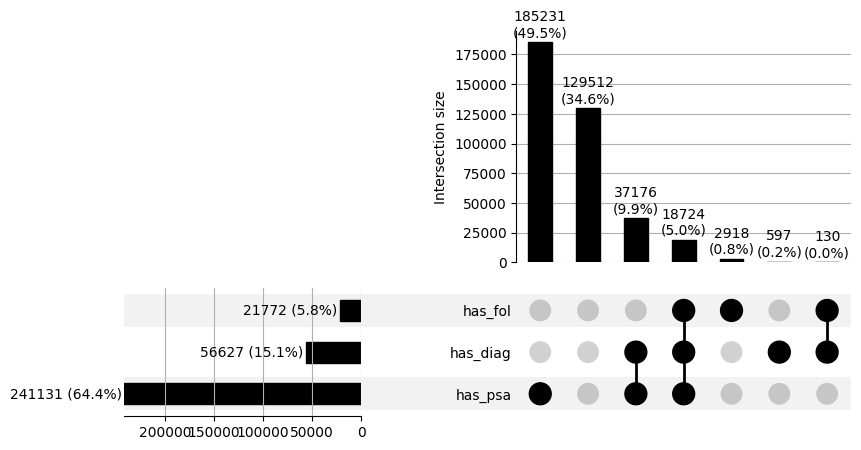

In [14]:
db_comb =con.sql("""--sql
    with t0 as (
        select PSA as psa, z_tum_id, z_kkr_label
        from Tumor
        where z_dy between 2020 and 2024
            and not z_is_dco
            and z_icd10_3d = 'C61'
    ),
    t1_diag as (
        select z_tum_id, count(*) as cnt
        from Diagnose_WeitereKlassifikation 
        where Name ilike '%psa%'
        and Stadium is not null
        group by all
    ),
    t1_fol as (
        select z_tum_id, count(*) as cnt
        from Folgeereignis_WeitereKlassifikation
        where Name ilike '%psa%'
        and Stadium is not null
        group by all
    ),
    t2 as (
        select
            --t0.z_tum_id,
            z_kkr_label,
            (psa is not null) as has_psa,
            (t1_diag.z_tum_id is not null) as has_diag,
            (t1_fol.z_tum_id is not null) as has_fol,
            t1_diag.cnt as cnt_psa_diag,
            t1_fol.cnt as cnt_psa_fol,
            case
                when psa is null and t1_diag.z_tum_id is null and t1_fol.z_tum_id is null then '1_all_null'
                when psa is not null and t1_diag.z_tum_id is null and t1_fol.z_tum_id is null then '2_psa_only'
                when psa is null and (t1_diag.z_tum_id is not null or t1_fol.z_tum_id is null) then '3_diag_fol_only'
                when psa is not null and t1_diag.z_tum_id is not null and t1_fol.z_tum_id is not null then '4_psa_diag_fol'
                when coalesce(psa::text, t1_diag.z_tum_id, t1_fol.z_tum_id) is not null then '5_mixed'
            else 'U' end as categ_psa
        from t0
        left join t1_diag on t0.z_tum_id = t1_diag.z_tum_id
        left join t1_fol on t0.z_tum_id = t1_fol.z_tum_id
    )
    select * from t2
""")

# db_comb.filter("categ_psa = 'U'").show()
# tbl.descr_db(db_comb, "db_comb")

pls.plot_stacked_bars(
    db_comb.project("z_kkr_label, categ_psa").to_df(),
    orientation="h",
    relative=True,
    show_total=True,
    show_pct_bar=True,
    first_col_grey=True,
)

pls.plot_upset(
    db_comb.project("columns('^has_')").to_df(),
    )

In [ ]:
if False:
    import pygwalker as pyg

    pyg.walk(
        db_class_agg.to_df().dropna(),
        kernel_computation=True,
    )